# Ferraro 2015 Result Comparison (`SpatialEffect2` vs commit `SpatialEffect`)

This notebook performs a step-by-step comparison mainly using `pandas`:

1. Load `.RData`
2. Normalize object formats to DataFrame
3. Align distance units (`sf` meters -> kilometers)
4. Compare key metrics (AME, smoothed AME, Conley CI)
5. Summarize key-window results (1-5 km)

In [15]:
# Step 1: Import dependencies and define file paths
from pathlib import Path
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# NumPy 2.x compatibility: some RData parsers still reference np.unicode_
if not hasattr(np, "unicode_"):
    np.unicode_ = np.str_

# Support different launch directories: auto-detect the data folder
candidates = [
    Path("../data"),
    Path("WangSamiiChangAronow_2024_replication/application/data"),
    Path("./application/data"),
]

DATA_DIR = None
for c in candidates:
    if (c / "Ferraro_etal_2015_sf.RData").exists() and (c / "forestResult_reproj.RData").exists():
        DATA_DIR = c
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Data directory not found. Please check the current working directory or set DATA_DIR manually."
    )

SF_RDATA = DATA_DIR / "Ferraro_etal_2015_sf.RData"
OLD_RDATA = DATA_DIR / "forestResult_reproj.RData"

print("DATA_DIR:", DATA_DIR.resolve())
print("SF file:", SF_RDATA.resolve())
print("Old-result file:", OLD_RDATA.resolve())
print("Files exist:", SF_RDATA.exists(), OLD_RDATA.exists())

DATA_DIR: /Users/zheqiao/Documents/cursor_projects/SpatialEffectPackage/WangSamiiChangAronow_2024_replication/application/data
SF file: /Users/zheqiao/Documents/cursor_projects/SpatialEffectPackage/WangSamiiChangAronow_2024_replication/application/data/Ferraro_etal_2015_sf.RData
Old-result file: /Users/zheqiao/Documents/cursor_projects/SpatialEffectPackage/WangSamiiChangAronow_2024_replication/application/data/forestResult_reproj.RData
Files exist: True True


In [16]:
# Step 2: Load .RData (prefer pyreadr, fallback to rdata automatically)
def _normalize_keys(d):
    if isinstance(d, dict):
        return {str(k): v for k, v in d.items()}
    return d


def read_rdata_result_list(path: Path):
    """Return result.list from an RData file (as a Python dict)."""
    try:
        import pyreadr
        obj = pyreadr.read_r(str(path))
        obj = _normalize_keys(obj)
        if "result.list" in obj:
            return _normalize_keys(obj["result.list"])
        if len(obj.keys()) == 1:
            return _normalize_keys(next(iter(obj.values())))
        raise KeyError(f"result.list not found in pyreadr object: {list(obj.keys())}")
    except Exception:
        print(f"[info] pyreadr does not support {path.name}; falling back to rdata.")

    import rdata
    obj = _normalize_keys(rdata.read_rda(str(path)))
    if "result.list" in obj:
        return _normalize_keys(obj["result.list"])
    if len(obj.keys()) == 1:
        return _normalize_keys(next(iter(obj.values())))
    raise KeyError(f"result.list not found in rdata object: {list(obj.keys())}")


sf_result = read_rdata_result_list(SF_RDATA)
old_result = read_rdata_result_list(OLD_RDATA)

print("sf_result type:", type(sf_result))
print("old_result type:", type(old_result))
print("sf keys:", list(sf_result.keys()))
print("old keys:", list(old_result.keys()))

[info] pyreadr does not support Ferraro_etal_2015_sf.RData; falling back to rdata.
[info] pyreadr does not support forestResult_reproj.RData; falling back to rdata.
sf_result type: <class 'dict'>
old_result type: <class 'dict'>
sf keys: ['AMR_est', 'Per.CI', 'Conley.SE', 'Conley.CI', 'AMR_est_smoothed', 'smoothed.Conley.SE', 'smoothed.Conley.CI', 'Parameters', 'call']
old keys: ['AMR_est', 'Per.CI', 'Conley.SE', 'Conley.CI', 'AMR_est_smoothed', 'smoothed.Conley.SE', 'smoothed.Conley.CI', 'Parameters', 'call']


In [17]:
# Step 3: Normalize objects into DataFrames for pandas comparison

def to_dataframe(x, columns=None):
    if isinstance(x, pd.DataFrame):
        out = x.copy()
    elif hasattr(x, "to_pandas"):  # xarray.DataArray
        out = x.to_pandas()
        if not isinstance(out, pd.DataFrame):
            out = pd.DataFrame(out)
    else:
        out = pd.DataFrame(np.asarray(x))

    out = out.reset_index(drop=True)
    if columns is not None and out.shape[1] == len(columns):
        out.columns = columns
    return out


sf_ame = to_dataframe(sf_result["AMR_est"], columns=["d", "est_sf"])
old_ame = to_dataframe(old_result["AMR_est"], columns=["d", "est_old"])

sf_sm = to_dataframe(sf_result["AMR_est_smoothed"], columns=["d", "est_sf_sm"])
old_sm = to_dataframe(old_result["AMR_est_smoothed"], columns=["d", "est_old_sm"])

sf_ci = to_dataframe(sf_result["Conley.CI"], columns=["ci_l_sf", "ci_u_sf"])
sf_ci.insert(0, "d", sf_ame["d"].values)

old_ci = to_dataframe(old_result["Conley.CI"], columns=["ci_l_old", "ci_u_old"])
old_ci.insert(0, "d", old_ame["d"].values)

print("sf_ame shape:", sf_ame.shape, "old_ame shape:", old_ame.shape)
print("sf_sm shape:", sf_sm.shape, "old_sm shape:", old_sm.shape)
print("sf_ci shape:", sf_ci.shape, "old_ci shape:", old_ci.shape)

sf_ame.head()

sf_amr shape: (41, 2) old_amr shape: (31, 2)
sf_sm shape: (41, 2) old_sm shape: (31, 2)
sf_ci shape: (41, 3) old_ci shape: (31, 3)


,d,est_sf
0,0.000000,-0.010820
1,500.000000,-0.004247
2,1000.000000,-0.010742
3,1500.000000,-0.005786
4,2000.000000,-0.007307


In [18]:
# Step 4: Align distance units (sf: meters, old: kilometers) and build comparable samples

def align_by_km(sf_df, old_df, sf_d_col="d", old_d_col="d"):
    a = sf_df.copy()
    b = old_df.copy()

    a["km"] = a[sf_d_col] / 1000.0
    b["km"] = b[old_d_col].astype(float)

    # Keep only integer-km points from sf to align with old results
    a = a[np.isclose(a["km"], np.round(a["km"]))].copy()
    a["km"] = a["km"].round().astype(int)
    b["km"] = b["km"].round().astype(int)

    out = pd.merge(a.drop(columns=[sf_d_col]), b.drop(columns=[old_d_col]), on="km", how="inner")
    return out.sort_values("km").reset_index(drop=True)


ame_aligned = align_by_km(sf_ame, old_ame)
sm_aligned = align_by_km(sf_sm, old_sm)
ci_aligned = align_by_km(sf_ci, old_ci)

print("ame_aligned:", ame_aligned.shape)
print("sm_aligned:", sm_aligned.shape)
print("ci_aligned:", ci_aligned.shape)
ame_aligned.head()

amr_aligned: (21, 3)
sm_aligned: (21, 3)
ci_aligned: (21, 5)


,est_sf,km,est_old
0,-0.010820,0,-0.012691
1,-0.010742,1,-0.009009
2,-0.007307,2,-0.008243
3,-0.008277,3,-0.008550
4,-0.005211,4,-0.006849


In [19]:
# Step 5: Define comparison functions for key metrics

def compare_series(df, sf_col, old_col, name, window=(1, 5)):
    d = df.copy()
    d = d[np.isfinite(d[sf_col]) & np.isfinite(d[old_col])].copy()
    d["diff"] = d[sf_col] - d[old_col]

    metrics = {
        "metric": name,
        "n": len(d),
        "km_min": int(d["km"].min()),
        "km_max": int(d["km"].max()),
        "mean_sf": d[sf_col].mean(),
        "mean_old": d[old_col].mean(),
        "mean_diff": d["diff"].mean(),
        "mae": d["diff"].abs().mean(),
        "rmse": np.sqrt((d["diff"] ** 2).mean()),
        "max_abs_diff": d["diff"].abs().max(),
        "corr": d[[sf_col, old_col]].corr().iloc[0, 1],
        "sign_mismatch_rate": (np.sign(d[sf_col]) != np.sign(d[old_col])).mean(),
    }

    w = d[(d["km"] >= window[0]) & (d["km"] <= window[1])].copy()
    if len(w) > 0:
        metrics.update({
            "window": f"{window[0]}-{window[1]}km",
            "window_mean_sf": w[sf_col].mean(),
            "window_mean_old": w[old_col].mean(),
            "window_mean_diff": (w[sf_col] - w[old_col]).mean(),
        })

    top = d.reindex(d["diff"].abs().sort_values(ascending=False).index).head(5)
    return pd.DataFrame([metrics]), top[["km", sf_col, old_col, "diff"]]


def compare_ci_width(ci_df, eps=1e-6):
    d0 = ci_df.copy()
    total_n = len(d0)

    cols = ["ci_l_sf", "ci_u_sf", "ci_l_old", "ci_u_old"]
    d = d0.copy()
    for c in cols:
        d = d[np.isfinite(d[c])]

    # Defensive step: ensure lower <= upper
    d["sf_low"] = np.minimum(d["ci_l_sf"], d["ci_u_sf"])
    d["sf_up"] = np.maximum(d["ci_l_sf"], d["ci_u_sf"])
    d["old_low"] = np.minimum(d["ci_l_old"], d["ci_u_old"])
    d["old_up"] = np.maximum(d["ci_l_old"], d["ci_u_old"])

    d["width_sf"] = d["sf_up"] - d["sf_low"]
    d["width_old"] = d["old_up"] - d["old_low"]

    # Pointwise ratio can be inflated by tiny denominators; compute robust version separately
    d_ratio = d[d["width_old"] > eps].copy()
    d_ratio["width_ratio_sf_over_old"] = d_ratio["width_sf"] / d_ratio["width_old"]

    out = pd.DataFrame([
        {
            "metric": "Conley_CI_width",
            "n_total_aligned": total_n,
            "n_finite": len(d),
            "n_missing_or_nonfinite": total_n - len(d),
            "mean_width_sf": d["width_sf"].mean(),
            "mean_width_old": d["width_old"].mean(),
            "overall_ratio_mean_width_sf_over_old": d["width_sf"].mean() / d["width_old"].mean(),
            "median_pointwise_ratio_sf_over_old": d_ratio["width_ratio_sf_over_old"].median(),
        }
    ])

    detail = d[["km", "width_sf", "width_old"]].copy()
    detail = detail.merge(
        d_ratio[["km", "width_ratio_sf_over_old"]],
        on="km",
        how="left",
    )

    return out, detail

In [20]:
# Step 6: Compute and display main comparison metrics
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

ame_summary, ame_top5 = compare_series(ame_aligned, "est_sf", "est_old", "AME_est_unsmoothed")
sm_summary, sm_top5 = compare_series(sm_aligned, "est_sf_sm", "est_old_sm", "AME_est_smoothed")
ci_summary, ci_width_detail = compare_ci_width(ci_aligned)

summary = pd.concat([ame_summary, sm_summary], ignore_index=True)
summary

,metric,n,km_min,km_max,mean_sf,mean_old,mean_diff,mae,rmse,max_abs_diff,corr,sign_mismatch_rate,window,window_mean_sf,window_mean_old,window_mean_diff
0,AMR_est_unsmoothed,21,0,20,-0.003329,-0.003660,0.000332,0.001415,0.001666,0.002894,0.899120,0.238095,1-5km,-0.007165,-0.007922,0.000757
1,AMR_est_smoothed,21,0,20,-0.003305,-0.003705,0.000400,0.001108,0.001353,0.003364,0.983226,0.095238,1-5km,-0.006594,-0.008160,0.001566


In [21]:
# Step 7: Show distance points with the largest differences (Top 5)
print("AME_est_unsmoothed Top-5 differences")
display(ame_top5)

print("AME_est_smoothed Top-5 differences")
display(sm_top5)

AMR_est_unsmoothed Top-5 differences


,km,est_sf,est_old,diff
6,6,-0.003666,-0.006560,0.002894
20,20,-0.002295,0.000486,-0.002782
10,10,0.000296,-0.002382,0.002678
5,5,-0.004289,-0.006960,0.002671
17,17,0.001720,-0.000597,0.002317


AMR_est_smoothed Top-5 differences


,km,est_sf_sm,est_old_sm,diff
0,0,-0.008742,-0.012106,0.003364
1,1,-0.008076,-0.010009,0.001933
6,6,-0.003751,-0.005611,0.001859
5,5,-0.004726,-0.006584,0.001857
20,20,-0.001415,0.000420,-0.001834


In [22]:
# Step 8: Compare Conley CI widths (is sf narrower?)
ci_summary

,metric,n_total_aligned,n_finite,n_missing_or_nonfinite,mean_width_sf,mean_width_old,overall_ratio_mean_width_sf_over_old,median_pointwise_ratio_sf_over_old
0,Conley_CI_width,21,18,3,0.009018,0.014060,0.641348,0.564151


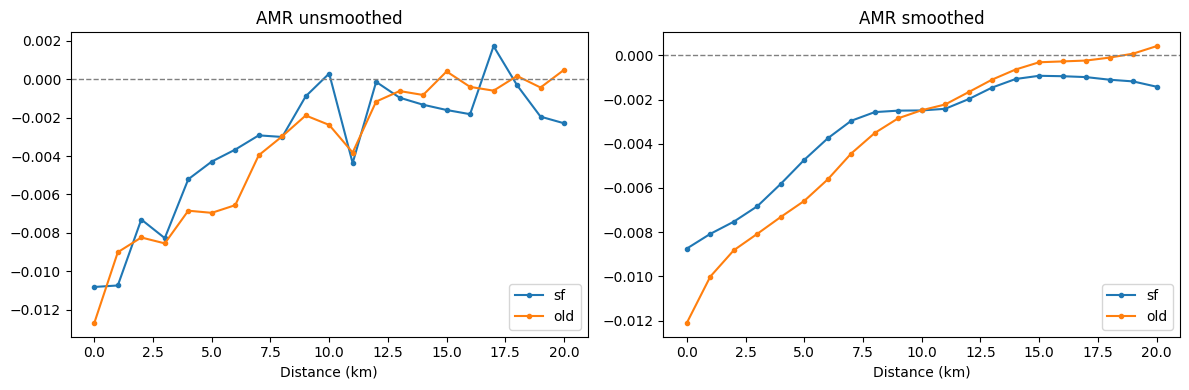

In [23]:
# Step 9: Optional plots (quick visual comparison)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(ame_aligned["km"], ame_aligned["est_sf"], label="sf", marker="o", ms=3)
axes[0].plot(ame_aligned["km"], ame_aligned["est_old"], label="old", marker="o", ms=3)
axes[0].axhline(0, color="gray", ls="--", lw=1)
axes[0].set_title("AME unsmoothed")
axes[0].set_xlabel("Distance (km)")
axes[0].legend()

axes[1].plot(sm_aligned["km"], sm_aligned["est_sf_sm"], label="sf", marker="o", ms=3)
axes[1].plot(sm_aligned["km"], sm_aligned["est_old_sm"], label="old", marker="o", ms=3)
axes[1].axhline(0, color="gray", ls="--", lw=1)
axes[1].set_title("AME smoothed")
axes[1].set_xlabel("Distance (km)")
axes[1].legend()

plt.tight_layout()
plt.show()